In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy import stats

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


# Import data

In [2]:
path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'
HI_dmax = xr.open_dataset(path+'dailymax_HI.nc')
ATL3 = xr.open_dataset(path+'ATL3.nc')
ONI = xr.open_dataset(path+'ONI.nc')
CANI_EANI = xr.open_dataset(path+'CANI_EANI.nc')
HI_dmax_month_anom = xr.open_dataset(path+'HI_dmax_month_anom.nc')

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RH = xr.open_dataset(path+'RHanom_during_HIdmax.nc')
T  = xr.open_dataset(path+'Tanom_during_HIdmax.nc')
U  = xr.open_dataset(path+'U_Hidmax_anom.nc')
V  = xr.open_dataset(path+'V_Hidmax_anom.nc')

In [4]:
idate = '1940-01-01'
fdate = '2025-12-31'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
ATL3 = ATL3['ATL3'].sel(valid_time=slice(idate, fdate))
ONI = ONI['ONI'].sel(valid_time=slice(idate, fdate))
HI_dmax_month_anom = HI_dmax_month_anom['HI_dmax_anom'].sel(time=slice(idate, fdate))
RH = RH['RHanom_during_HIdmax'].sel(time=slice(idate, fdate))
T = T['Tanom_during_HIdmax'].sel(time=slice(idate, fdate))
U = U['U10_HIdmax_anom'].sel(time=slice(idate, fdate))
V = V['V10_HIdmax_anom'].sel(time=slice(idate, fdate))
CANI = CANI_EANI['CANI'].sel(time=slice(idate, fdate))
EANI = CANI_EANI['EANI'].sel(time=slice(idate, fdate))

In [5]:
#  mix u and v to a single dataset
UV = xr.merge([U, V], compat='equals')
UV

<xarray.Dataset> Size: 2GB
Dimensions:          (latitude: 82, longitude: 121, time: 31412)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
  * time             (time) datetime64[ns] 251kB 1940-01-01 ... 2025-12-31
    month            (time) int64 251kB 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12
Data variables:
    U10_HIdmax_anom  (time, latitude, longitude) float32 1GB ...
    V10_HIdmax_anom  (time, latitude, longitude) float32 1GB ...

# ERS Selection

In [6]:
def me_mean(ds):
    meds = ds.resample(time='ME').mean()
    return meds


meHI_dmax = me_mean(HI_dmax)
meRH = me_mean(RH)
meT = me_mean(T)
meUV = me_mean(UV)

In [7]:
ERS = [4, 5, 6, 7]
ERS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(ERS), drop=True)
ERS_ATL3 = ATL3.where(ATL3.valid_time.dt.month.isin(ERS), drop=True)
ERS_ONI = ONI.where(ONI.valid_time.dt.month.isin(ERS), drop=True)
ERS_RH = meRH.where(meRH.time.dt.month.isin(ERS), drop=True)
ERS_T = meT.where(meT.time.dt.month.isin(ERS), drop=True)
ERS_UV = meUV.where(meUV.time.dt.month.isin(ERS), drop=True)
ERS_CANI = CANI.where(CANI.time.dt.month.isin(ERS), drop=True)
ERS_EANI = EANI.where(EANI.time.dt.month.isin(ERS), drop=True)

In [8]:
ERS_CANI_y = ERS_CANI.resample(time='YE').mean()
ERS_EANI_y = ERS_EANI.resample(time='YE').mean()
ERS_ATL3_y = ERS_ATL3.resample(valid_time='YE').mean().rename({'valid_time': 'time'})
ERS_ONI_y = ERS_ONI.resample(valid_time='YE').mean().rename({'valid_time': 'time'})

# LRS Selection

In [9]:
LRS = [8, 9, 10, 11]
LRS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(LRS), drop=True)
LRS_ATL3 = ATL3.where(ATL3.valid_time.dt.month.isin(LRS), drop=True)
LRS_ONI = ONI.where(ONI.valid_time.dt.month.isin(LRS), drop=True)
LRS_RH = meRH.where(meRH.time.dt.month.isin(LRS), drop=True)
LRS_T = meT.where(meT.time.dt.month.isin(LRS), drop=True)
LRS_UV = meUV.where(meUV.time.dt.month.isin(LRS), drop=True)
LRS_CANI = CANI.where(CANI.time.dt.month.isin(LRS), drop=True)
LRS_EANI = EANI.where(EANI.time.dt.month.isin(LRS), drop=True)

In [10]:
LRS_CANI_y = LRS_CANI.resample(time='YE').mean()
LRS_EANI_y = LRS_EANI.resample(time='YE').mean()
LRS_ATL3_y = LRS_ATL3.resample(valid_time='YE').mean().rename({'valid_time': 'time'})
LRS_ONI_y = LRS_ONI.resample(valid_time='YE').mean().rename({'valid_time': 'time'})

# Phase Convo

In [11]:
def niño(ds):
    return ds >= 0.5


def niña(ds):
    return ds <= -0.5


def neutral(ds):
    return ((ds > -0.5) & (ds < 0.5) )


def wn_cond(ds1, ds2):
    return (niño(ds1) & (neutral(ds2)))


def cn_cond(ds1, ds2):
    return (niña(ds1) & (neutral(ds2)))

## +ATL3 and Neutral ONI

In [12]:
ATLo_ERSy = ERS_ATL3_y.time.dt.year.where(wn_cond(ERS_ATL3_y, ERS_ONI_y), drop=True)
ATLo_ERSy

<xarray.DataArray 'year' (time: 7)> Size: 56B
array([1963., 1991., 1995., 2009., 2010., 2021., 2023.])
Coordinates:
  * time     (time) datetime64[ns] 56B 1963-12-31 1991-12-31 ... 2023-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [13]:
ATLo_LRSy = LRS_ATL3_y.time.dt.year.where(wn_cond(LRS_ATL3_y, LRS_ONI_y), drop=True)
ATLo_LRSy

<xarray.DataArray 'year' (time: 7)> Size: 56B
array([1963., 2003., 2008., 2016., 2018., 2019., 2021.])
Coordinates:
  * time     (time) datetime64[ns] 56B 1963-12-31 2003-12-31 ... 2021-12-31
Attributes:
    long_name:      time
    standard_name:  time

## -ATL3 and Neutral ONI

In [14]:
ATLa_ERSy = ERS_ATL3_y.time.dt.year.where(cn_cond(ERS_ATL3_y, ERS_ONI_y), drop=True)
ATLa_ERSy

<xarray.DataArray 'year' (time: 4)> Size: 32B
array([1948., 1954., 1977., 1978.])
Coordinates:
  * time     (time) datetime64[ns] 32B 1948-12-31 1954-12-31 ... 1978-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [15]:
ATLa_LRSy = LRS_ATL3_y.time.dt.year.where(cn_cond(LRS_ATL3_y, LRS_ONI_y), drop=True)
ATLa_LRSy

<xarray.DataArray 'year' (time: 8)> Size: 64B
array([1944., 1945., 1946., 1958., 1967., 1976., 1978., 1992.])
Coordinates:
  * time     (time) datetime64[ns] 64B 1944-12-31 1945-12-31 ... 1992-12-31
Attributes:
    long_name:      time
    standard_name:  time

## +ONI and Neutral ATL3

In [16]:
ONIo_ERSy = ERS_ONI_y.time.dt.year.where(wn_cond(ERS_ONI_y, ERS_ATL3_y), drop=True)
ONIo_ERSy

<xarray.DataArray 'year' (time: 13)> Size: 104B
array([1940., 1941., 1953., 1957., 1959., 1966., 1969., 1982., 1987.,
       1993., 2015., 2016., 2019.])
Coordinates:
  * time     (time) datetime64[ns] 104B 1940-12-31 1941-12-31 ... 2019-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [17]:
ONIo_LRSy = LRS_ONI_y.time.dt.year.where(wn_cond(LRS_ONI_y, LRS_ATL3_y), drop=True)
ONIo_LRSy

<xarray.DataArray 'year' (time: 17)> Size: 136B
array([1940., 1941., 1951., 1953., 1965., 1966., 1972., 1986., 1991.,
       1994., 1997., 2002., 2004., 2006., 2009., 2012., 2015.])
Coordinates:
  * time     (time) datetime64[ns] 136B 1940-12-31 1941-12-31 ... 2015-12-31
Attributes:
    long_name:      time
    standard_name:  time

## -ONI and Neutral ATL3

In [18]:
ONIa_ERSy = ERS_ONI_y.time.dt.year.where(cn_cond(ERS_ONI_y, ERS_ATL3_y), drop=True)
ONIa_ERSy

<xarray.DataArray 'year' (time: 13)> Size: 104B
array([1950., 1955., 1962., 1964., 1971., 1974., 1975., 1981., 1985.,
       1989., 2000., 2011., 2022.])
Coordinates:
  * time     (time) datetime64[ns] 104B 1950-12-31 1955-12-31 ... 2022-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [19]:
ONIa_LRSy = LRS_ONI_y.time.dt.year.where(cn_cond(LRS_ONI_y, LRS_ATL3_y), drop=True)
ONIa_LRSy

<xarray.DataArray 'year' (time: 12)> Size: 96B
array([1942., 1955., 1962., 1970., 1971., 1973., 1975., 1995., 2007.,
       2011., 2020., 2022.])
Coordinates:
  * time     (time) datetime64[ns] 96B 1942-12-31 1955-12-31 ... 2022-12-31
Attributes:
    long_name:      time
    standard_name:  time

## +CAN and neutral ONI

# useful stuff

In [20]:
def get_comp(var_ds, years):
    var_comp = var_ds.where(var_ds.time.dt.year.isin(years.values), drop=True)
    return var_comp.mean('time')


sig_threshold = 0.90
def random_comp_dist(var_ds, comp_size,iter=1000, sig=sig_threshold):
    draw = np.random.choice(var_ds.time, size=(iter, comp_size), replace=True)
    idx = xr.DataArray(draw, dims=['iteration', 'sample'], coords={'iteration': np.arange(iter)})
    
    rand_comp_dist = var_ds.sel(time=idx).mean('sample')

    l_sig = (1 - sig) / 2
    h_sig = 1 - l_sig
    results = rand_comp_dist.quantile([l_sig, h_sig], dim='iteration')
    return results


def sel_sig(ds, filter):
    # takes dataset and qunatiles from random distribution of composites
    l_bound = filter.sel(quantile=0.05, method='nearest')
    h_bound = filter.sel(quantile=0.95, method='nearest')
    sig_mask = (ds < l_bound) | (ds > h_bound)
    sig_ds = ds.where(sig_mask)
    return sig_ds

# <span style="color: orange"> Warm ATL3 and Neutral ONI<span/>

## Phases Comps

In [21]:
ERS_HI_comp_ATLo = get_comp(ERS_HI_dmax_anom, ATLo_ERSy)
ERS_T_comp_ATLo = get_comp(ERS_T, ATLo_ERSy)
ERS_RH_comp_ATLo = get_comp(ERS_RH, ATLo_ERSy)
ERS_UV_comp_ATLo = get_comp(ERS_UV, ATLo_ERSy)

In [22]:
LRS_HI_comp_ATLo = get_comp(LRS_HI_dmax_anom, ATLo_LRSy)
LRS_T_comp_ATLo = get_comp(LRS_T, ATLo_LRSy)
LRS_UV_comp_ATLo = get_comp(LRS_UV, ATLo_LRSy)
LRS_RH_comp_ATLo = get_comp(LRS_RH, ATLo_LRSy)

## Random Composites

In [23]:
ERS_HI_MCBS = random_comp_dist(ERS_HI_dmax_anom, ATLo_ERSy.sizes['time'])
ERS_T_MCBS = random_comp_dist(ERS_T, ATLo_ERSy.sizes['time'])
ERS_RH_MCBS = random_comp_dist(ERS_RH, ATLo_ERSy.sizes['time'])

ERS_U_MCBS = random_comp_dist(ERS_UV['U10_HIdmax_anom'], ATLo_ERSy.sizes['time'])
ERS_V_MCBS = random_comp_dist(ERS_UV['V10_HIdmax_anom'], ATLo_ERSy.sizes['time'])

In [24]:
LRS_HI_MCBS = random_comp_dist(LRS_HI_dmax_anom, ATLo_LRSy.sizes['time'])
LRS_T_MCBS = random_comp_dist(LRS_T, ATLo_LRSy.sizes['time'])
LRS_RH_MCBS = random_comp_dist(LRS_RH, ATLo_LRSy.sizes['time'])

LRS_U_MCBS = random_comp_dist(LRS_UV['U10_HIdmax_anom'], ATLo_LRSy.sizes['time'])
LRS_V_MCBS = random_comp_dist(LRS_UV['V10_HIdmax_anom'], ATLo_LRSy.sizes['time'])

## Filter

In [25]:
ERS_HI_sig = sel_sig(ERS_HI_comp_ATLo, ERS_HI_MCBS)
ERS_T_sig = sel_sig(ERS_T_comp_ATLo, ERS_T_MCBS)
ERS_RH_sig = sel_sig(ERS_RH_comp_ATLo, ERS_RH_MCBS)

In [26]:
ERS_U_sig = sel_sig(ERS_UV_comp_ATLo['U10_HIdmax_anom'], ERS_U_MCBS)
ERS_V_sig = sel_sig(ERS_UV_comp_ATLo['V10_HIdmax_anom'], ERS_V_MCBS)
ERS_UV_sig = xr.merge([ERS_U_sig.rename('U'), ERS_V_sig.rename('V')])

In [27]:
LRS_HI_sig = sel_sig(LRS_HI_comp_ATLo, LRS_HI_MCBS)
LRS_T_sig = sel_sig(LRS_T_comp_ATLo, LRS_T_MCBS)
LRS_RH_sig = sel_sig(LRS_RH_comp_ATLo, LRS_RH_MCBS)

In [28]:
LRS_U_sig = sel_sig(LRS_UV_comp_ATLo['U10_HIdmax_anom'], LRS_U_MCBS)
LRS_V_sig = sel_sig(LRS_UV_comp_ATLo['V10_HIdmax_anom'], LRS_V_MCBS)
LRS_UV_sig = xr.merge([LRS_U_sig.rename('U'), LRS_V_sig.rename('V')])

## Plots

### <span style="color: orange"> ERS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during ERS with +ATL3 and neutral ONI(n=7y, Sig=90.0%)')

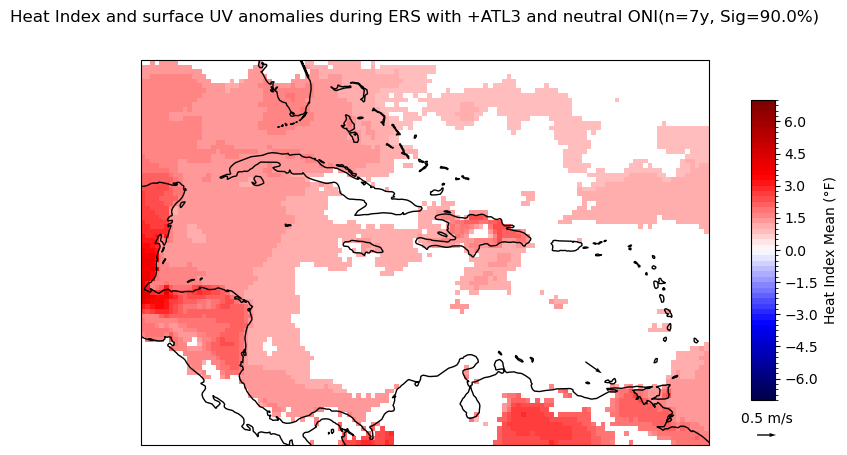

In [29]:
ERS_HI_sig_plot = ERS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = ERS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = ERS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

ERS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during ERS with +ATL3 and neutral ONI(n={ATLo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during ERS with +ATL3 and neutral ONI (n=7y, Sig=90.0%)')

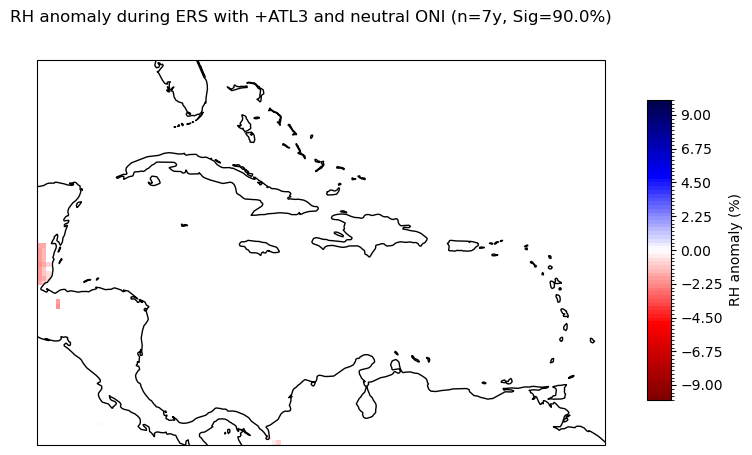

In [30]:
ERS_RH_sig_plot = ERS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

ERS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during ERS with +ATL3 and neutral ONI (n={ATLo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during ERS with +ATL3 and neutral ONI (n=7y, Sig=90.0%)')

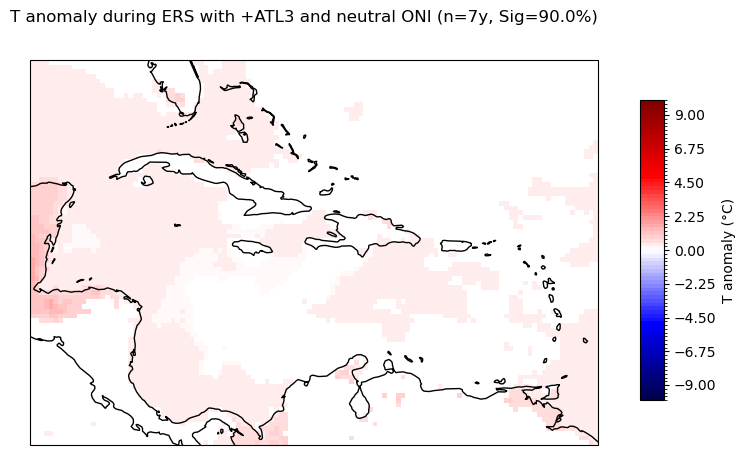

In [31]:
ERS_T_sig_plot = ERS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

ERS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during ERS with +ATL3 and neutral ONI (n={ATLo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

### <span style="color: orange"> LRS <span/>

#### HI

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during LRS with +ATL3 and neutral ONI (n=7y, Sig=90.0%)')

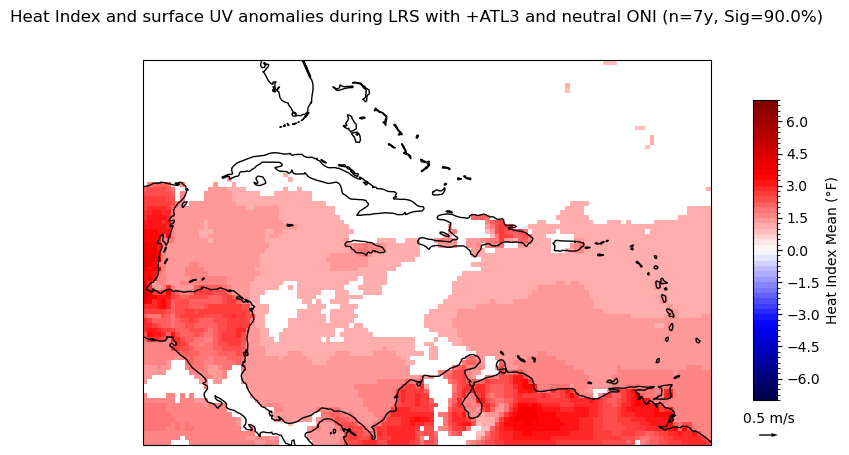

In [32]:
LRS_HI_sig_plot = LRS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = LRS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = LRS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

LRS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during LRS with +ATL3 and neutral ONI (n={ATLo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during LRS with +ATL3 and neutral ONI (n=7y, Sig=90.0%)')

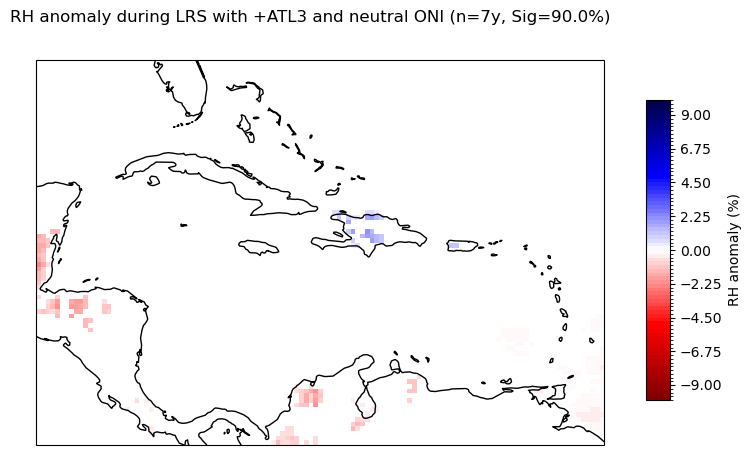

In [33]:
LRS_RH_sig_plot = LRS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

LRS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during LRS with +ATL3 and neutral ONI (n={ATLo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during LRS with +ATL3 and neutral ONI (n=7y, Sig=90.0%)')

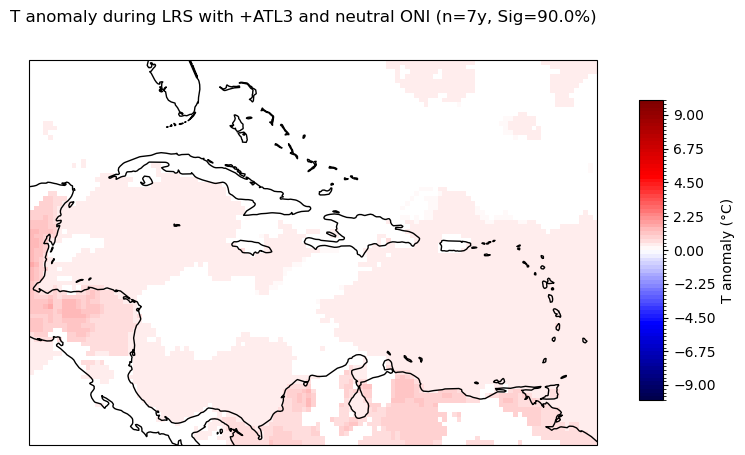

In [34]:
LRS_T_sig_plot = LRS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

LRS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during LRS with +ATL3 and neutral ONI (n={ATLo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

# <span style="color: orange">Warm ONI neutral ATL<span/>

## Phases Composites

In [35]:
ERS_HI_comp_ONIo = get_comp(ERS_HI_dmax_anom, ONIo_ERSy)
ERS_T_comp_ONIo = get_comp(ERS_T, ONIo_ERSy)
ERS_RH_comp_ONIo = get_comp(ERS_RH, ONIo_ERSy)
ERS_UV_comp_ONIo = get_comp(ERS_UV, ONIo_ERSy)

In [36]:
LRS_HI_comp_ONIo = get_comp(LRS_HI_dmax_anom, ONIo_LRSy)
LRS_T_comp_ONIo = get_comp(LRS_T, ONIo_LRSy)
LRS_RH_comp_ONIo = get_comp(LRS_RH, ONIo_LRSy)
LRS_UV_comp_ONIo = get_comp(LRS_UV, ONIo_LRSy)

## Random Composites

In [37]:
ERS_HI_MCBS = random_comp_dist(ERS_HI_dmax_anom, ONIo_ERSy.sizes['time'])
ERS_T_MCBS = random_comp_dist(ERS_T, ONIo_ERSy.sizes['time'])
ERS_RH_MCBS = random_comp_dist(ERS_RH, ONIo_ERSy.sizes['time'])

ERS_U_MCBS = random_comp_dist(ERS_UV['U10_HIdmax_anom'], ONIo_ERSy.sizes['time'])
ERS_V_MCBS = random_comp_dist(ERS_UV['V10_HIdmax_anom'], ONIo_ERSy.sizes['time'])

In [38]:
LRS_HI_MCBS = random_comp_dist(LRS_HI_dmax_anom, ONIo_LRSy.sizes['time'])
LRS_T_MCBS = random_comp_dist(LRS_T, ONIo_LRSy.sizes['time'])
LRS_RH_MCBS = random_comp_dist(LRS_RH, ONIo_LRSy.sizes['time'])

LRS_U_MCBS = random_comp_dist(LRS_UV['U10_HIdmax_anom'], ONIo_LRSy.sizes['time'])
LRS_V_MCBS = random_comp_dist(LRS_UV['V10_HIdmax_anom'], ONIo_LRSy.sizes['time'])

## Filtering

In [39]:
ERS_HI_sig = sel_sig(ERS_HI_comp_ONIo, ERS_HI_MCBS)
ERS_T_sig = sel_sig(ERS_T_comp_ONIo, ERS_T_MCBS)
ERS_RH_sig = sel_sig(ERS_RH_comp_ONIo, ERS_RH_MCBS)

ERS_U_sig = sel_sig(ERS_UV_comp_ONIo['U10_HIdmax_anom'], ERS_U_MCBS)
ERS_V_sig = sel_sig(ERS_UV_comp_ONIo['V10_HIdmax_anom'], ERS_V_MCBS)
ERS_UV_sig = xr.merge([ERS_U_sig.rename('U'), ERS_V_sig.rename('V')])

In [40]:
LRS_HI_sig = sel_sig(LRS_HI_comp_ONIo, LRS_HI_MCBS)
LRS_T_sig = sel_sig(LRS_T_comp_ONIo, LRS_T_MCBS)
LRS_RH_sig = sel_sig(LRS_RH_comp_ONIo, LRS_RH_MCBS)

LRS_U_sig = sel_sig(LRS_UV_comp_ONIo['U10_HIdmax_anom'], LRS_U_MCBS)
LRS_V_sig = sel_sig(LRS_UV_comp_ONIo['V10_HIdmax_anom'], LRS_V_MCBS)
LRS_UV_sig = xr.merge([LRS_U_sig.rename('U'), LRS_V_sig.rename('V')])

## Plots

### <span style="color: orange"> ERS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during ERS with +ONI and neutral ATL3 (n=13y, Sig=90.0%)')

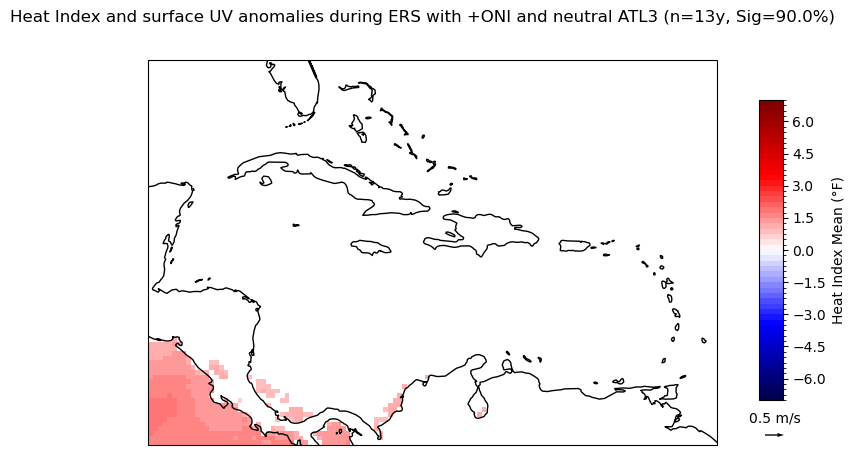

In [41]:
ERS_HI_sig_plot = ERS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = ERS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = ERS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

ERS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during ERS with +ONI and neutral ATL3 (n={ONIo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during ERS with +ONI and neutral ATL3 (n=13y, Sig=90.0%)')

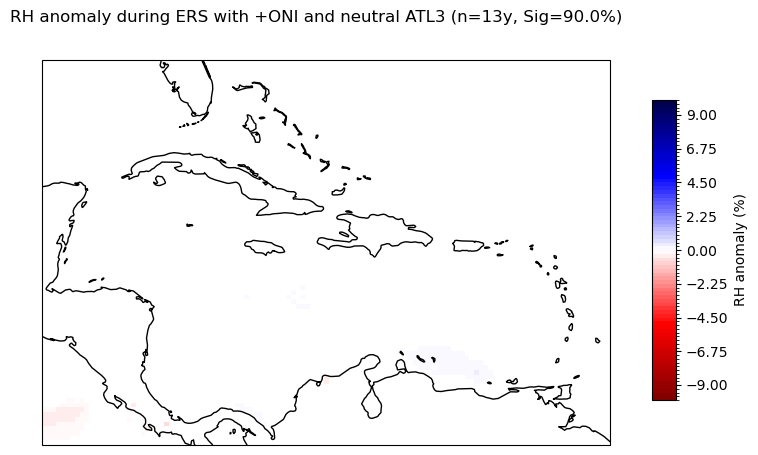

In [42]:
ERS_RH_sig_plot = ERS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

ERS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during ERS with +ONI and neutral ATL3 (n={ONIo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during ERS with +ONI and neutral ATL3 (n=13y, Sig=90.0%)')

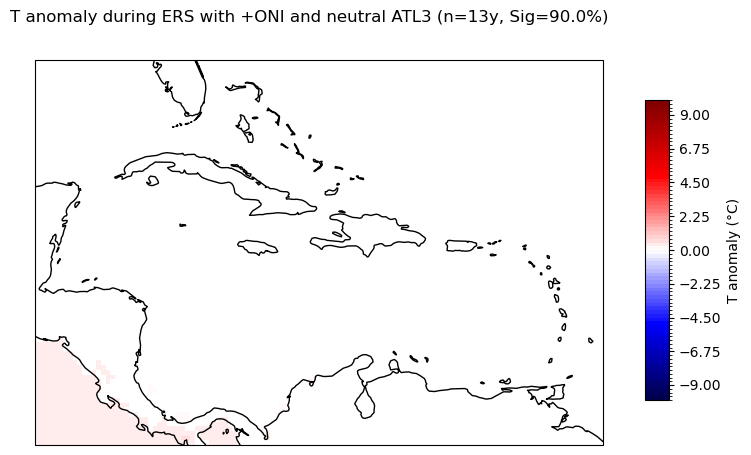

In [43]:
ERS_T_sig_plot = ERS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

ERS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during ERS with +ONI and neutral ATL3 (n={ONIo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

### <span style="color:orange"> LRS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during LRS with +ONI and neutral ATL3 (n=17y, Sig=90.0%)')

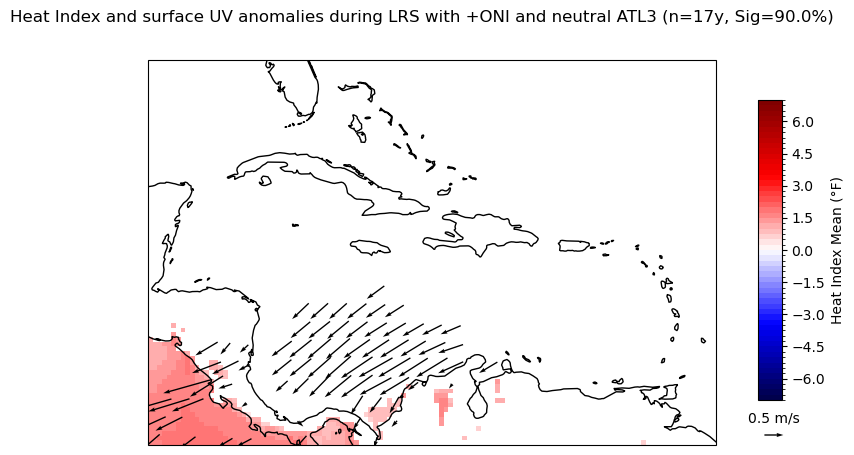

In [44]:
LRS_HI_sig_plot = LRS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = LRS_UV_sig.isel(longitude=slice(None, None, 4), latitude=slice(None, None, 4))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = LRS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

LRS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during LRS with +ONI and neutral ATL3 (n={ONIo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during LRS with +ONI and neutral ATL3 (n=7y, Sig=90.0%)')

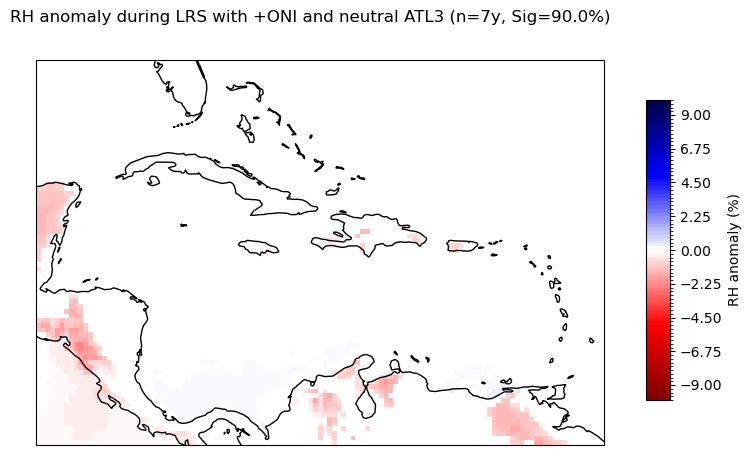

In [45]:
LRS_RH_sig_plot = LRS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

LRS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during LRS with +ONI and neutral ATL3 (n={ONIo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during LRS with +ONI and neutral ATL3 (n=17y, Sig=90.0%)')

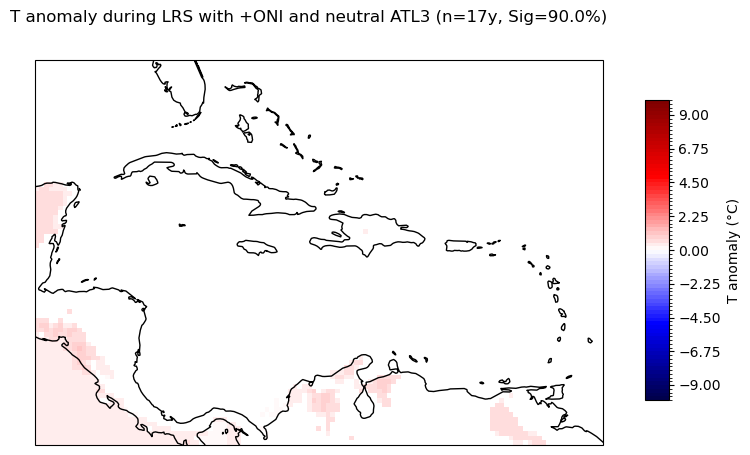

In [46]:
LRS_T_sig_plot = LRS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

LRS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during LRS with +ONI and neutral ATL3 (n={ONIo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

# <span style="color: orange"> Cold ATL3 and neutral ONI<span/>

## Phase Composites

In [48]:
ERS_HI_comp_ATLa = get_comp(ERS_HI_dmax_anom, ATLa_ERSy)
ERS_T_comp_ATLa = get_comp(ERS_T, ATLa_ERSy)
ERS_RH_comp_ATLa = get_comp(ERS_RH, ATLa_ERSy)
ERS_UV_comp_ATLa = get_comp(ERS_UV, ATLa_ERSy)

In [49]:
LRS_HI_comp_ATLa = get_comp(LRS_HI_dmax_anom, ATLa_LRSy)
LRS_T_comp_ATLa = get_comp(LRS_T, ATLa_LRSy)
LRS_RH_comp_ATLa = get_comp(LRS_RH, ATLa_LRSy)
LRS_UV_comp_ATLa = get_comp(LRS_UV, ATLa_LRSy)

## Random Composites

In [50]:
ERS_HI_MCBS = random_comp_dist(ERS_HI_dmax_anom, ATLa_ERSy.sizes['time'])
ERS_T_MCBS = random_comp_dist(ERS_T, ATLa_ERSy.sizes['time'])
ERS_RH_MCBS = random_comp_dist(ERS_RH, ATLa_ERSy.sizes['time'])

ERS_U_MCBS = random_comp_dist(ERS_UV['U10_HIdmax_anom'], ATLa_ERSy.sizes['time'])
ERS_V_MCBS = random_comp_dist(ERS_UV['V10_HIdmax_anom'], ATLa_ERSy.sizes['time'])

In [51]:
LRS_HI_MCBS = random_comp_dist(LRS_HI_dmax_anom, ATLa_LRSy.sizes['time'])
LRS_T_MCBS = random_comp_dist(LRS_T, ATLa_LRSy.sizes['time'])
LRS_RH_MCBS = random_comp_dist(LRS_RH, ATLa_LRSy.sizes['time'])

LRS_U_MCBS = random_comp_dist(LRS_UV['U10_HIdmax_anom'], ATLa_LRSy.sizes['time'])
LRS_V_MCBS = random_comp_dist(LRS_UV['V10_HIdmax_anom'], ATLa_LRSy.sizes['time'])

## Filtering

In [52]:
ERS_HI_sig = sel_sig(ERS_HI_comp_ATLa, ERS_HI_MCBS)
ERS_T_sig = sel_sig(ERS_T_comp_ATLa, ERS_T_MCBS)
ERS_RH_sig = sel_sig(ERS_RH_comp_ATLa, ERS_RH_MCBS)

ERS_U_sig = sel_sig(ERS_UV_comp_ATLa['U10_HIdmax_anom'], ERS_U_MCBS)
ERS_V_sig = sel_sig(ERS_UV_comp_ATLa['V10_HIdmax_anom'], ERS_V_MCBS)
ERS_UV_sig = xr.merge([ERS_U_sig.rename('U'), ERS_V_sig.rename('V')])

In [53]:
LRS_HI_sig = sel_sig(LRS_HI_comp_ATLa, LRS_HI_MCBS)
LRS_T_sig = sel_sig(LRS_T_comp_ATLa, LRS_T_MCBS)
LRS_RH_sig = sel_sig(LRS_RH_comp_ATLa, LRS_RH_MCBS)

LRS_U_sig = sel_sig(LRS_UV_comp_ATLa['U10_HIdmax_anom'], LRS_U_MCBS)
LRS_V_sig = sel_sig(LRS_UV_comp_ATLa['V10_HIdmax_anom'], LRS_V_MCBS)
LRS_UV_sig = xr.merge([LRS_U_sig.rename('U'), LRS_V_sig.rename('V')])

## Plots

### <span style="color: orange"> ERS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during ERS with -ATL3 and neutral ONI (n=4y, Sig=90.0%)')

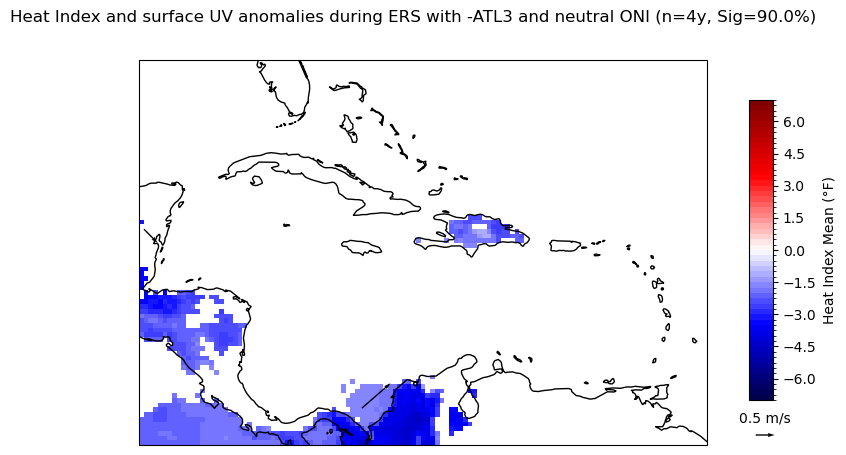

In [54]:
ERS_HI_sig_plot = ERS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = ERS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = ERS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

ERS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during ERS with -ATL3 and neutral ONI (n={ATLa_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during ERS with -ATL3 and neutral ONI (n=4y, Sig=90.0%)')

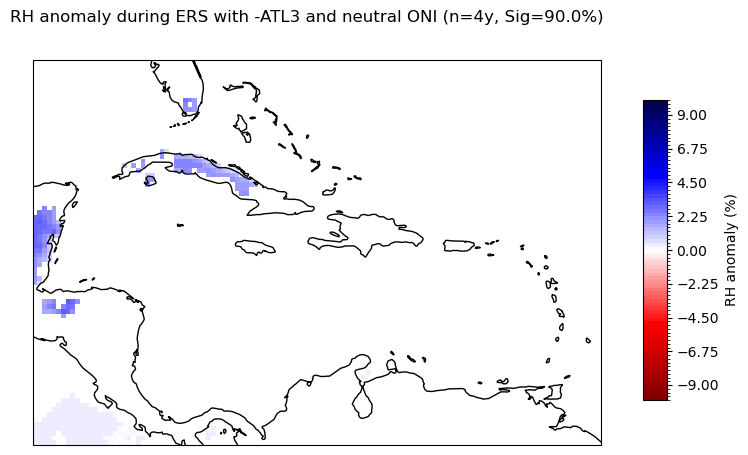

In [55]:
ERS_RH_sig_plot = ERS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

ERS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during ERS with -ATL3 and neutral ONI (n={ATLa_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during ERS with -ATL3 and neutral ONI (n=4y, Sig=90.0%)')

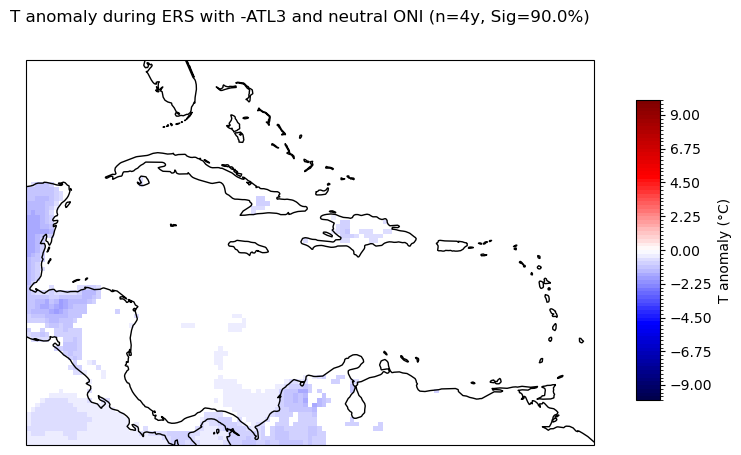

In [56]:
ERS_T_sig_plot = ERS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

ERS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during ERS with -ATL3 and neutral ONI (n={ATLa_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

### <span style="color: orange"> LRS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during LRS with -ATL3 and neutral ONI (n=8y, Sig=90.0%)')

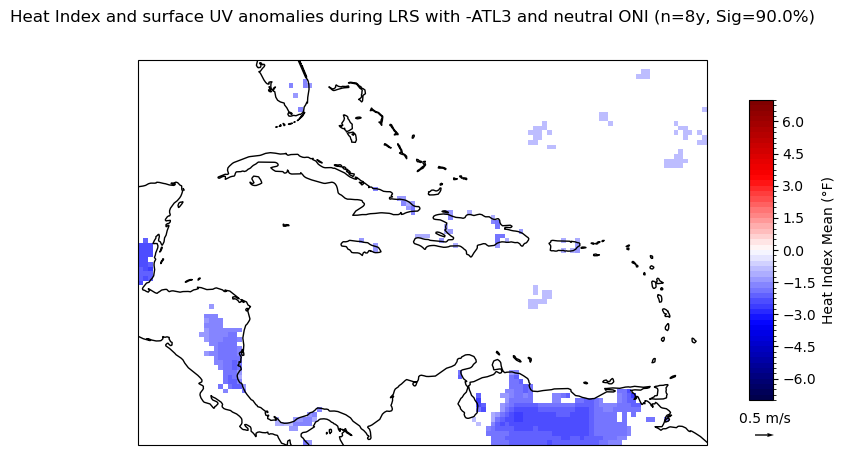

In [57]:
LRS_HI_sig_plot = LRS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = LRS_UV_sig.isel(longitude=slice(None, None, 4), latitude=slice(None, None, 4))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = LRS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

LRS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during LRS with -ATL3 and neutral ONI (n={ATLa_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during LRS with -ATL3 and neutral ONI (n=8y, Sig=90.0%)')

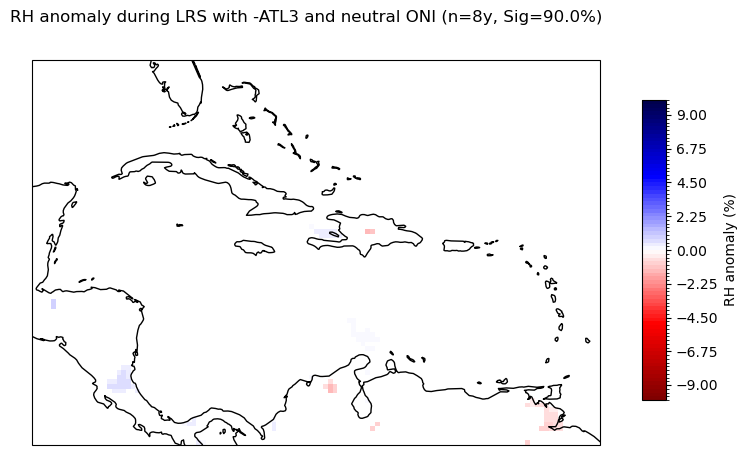

In [58]:
LRS_RH_sig_plot = LRS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

LRS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during LRS with -ATL3 and neutral ONI (n={ATLa_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during LRS with -ATl3 and neutral ONI (n=8y, Sig=90.0%)')

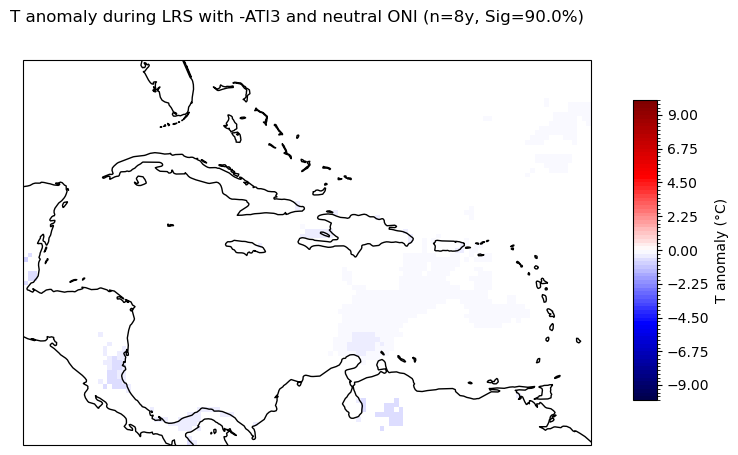

In [59]:
LRS_T_sig_plot = LRS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

LRS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during LRS with -ATl3 and neutral ONI (n={ATLa_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

# <span style="color: orange"> Cold ONI and neutral ATL<span/>

## Phase Composites

In [60]:
ERS_HI_comp_ONIa = get_comp(ERS_HI_dmax_anom, ONIa_ERSy)
ERS_T_comp_ONIa = get_comp(ERS_T, ONIa_ERSy)
ERS_RH_comp_ONIa = get_comp(ERS_RH, ONIa_ERSy)
ERS_UV_comp_ONIa = get_comp(ERS_UV, ONIa_ERSy)

In [66]:
LRS_HI_comp_ONIa = get_comp(LRS_HI_dmax_anom, ONIa_LRSy)
LRS_T_comp_ONIa = get_comp(LRS_T, ONIa_LRSy)
LRS_RH_comp_ONIa = get_comp(LRS_RH, ONIa_LRSy)
LRS_UV_comp_ONIa = get_comp(LRS_UV, ONIa_LRSy)

## Random Composites

In [67]:
ERS_HI_MCBS = random_comp_dist(ERS_HI_dmax_anom, ONIa_ERSy.sizes['time'])
ERS_T_MCBS = random_comp_dist(ERS_T, ONIa_ERSy.sizes['time'])
ERS_RH_MCBS = random_comp_dist(ERS_RH, ONIa_ERSy.sizes['time'])

ERS_U_MCBS = random_comp_dist(ERS_UV['U10_HIdmax_anom'], ONIa_ERSy.sizes['time'])
ERS_V_MCBS = random_comp_dist(ERS_UV['V10_HIdmax_anom'], ONIa_ERSy.sizes['time'])

In [68]:
LRS_HI_MCBS = random_comp_dist(LRS_HI_dmax_anom, ONIa_LRSy.sizes['time'])
LRS_T_MCBS = random_comp_dist(LRS_T, ONIa_LRSy.sizes['time'])
LRS_RH_MCBS = random_comp_dist(LRS_RH, ONIa_LRSy.sizes['time'])

LRS_U_MCBS = random_comp_dist(LRS_UV['U10_HIdmax_anom'], ONIa_LRSy.sizes['time'])
LRS_V_MCBS = random_comp_dist(LRS_UV['V10_HIdmax_anom'], ONIa_LRSy.sizes['time'])

## Filtering

In [69]:
ERS_HI_sig = sel_sig(ERS_HI_comp_ONIa, ERS_HI_MCBS)
ERS_T_sig = sel_sig(ERS_T_comp_ONIa, ERS_T_MCBS)
ERS_RH_sig = sel_sig(ERS_RH_comp_ONIa, ERS_RH_MCBS)

ERS_U_sig = sel_sig(ERS_UV_comp_ONIa['U10_HIdmax_anom'], ERS_U_MCBS)
ERS_V_sig = sel_sig(ERS_UV_comp_ONIa['V10_HIdmax_anom'], ERS_V_MCBS)
ERS_UV_sig = xr.merge([ERS_U_sig.rename('U'), ERS_V_sig.rename('V')])

In [70]:
LRS_HI_sig = sel_sig(LRS_HI_comp_ONIa, LRS_HI_MCBS)
LRS_T_sig = sel_sig(LRS_T_comp_ONIa, LRS_T_MCBS)
LRS_RH_sig = sel_sig(LRS_RH_comp_ONIa, LRS_RH_MCBS)

LRS_U_sig = sel_sig(LRS_UV_comp_ONIa['U10_HIdmax_anom'], LRS_U_MCBS)
LRS_V_sig = sel_sig(LRS_UV_comp_ONIa['V10_HIdmax_anom'], LRS_V_MCBS)
LRS_UV_sig = xr.merge([LRS_U_sig.rename('U'), LRS_V_sig.rename('V')])

## Plotting

### <span style="color: orange"> ERS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during ERS with -ONI and neutral ATL3 (n=13y, Sig=90.0%)')

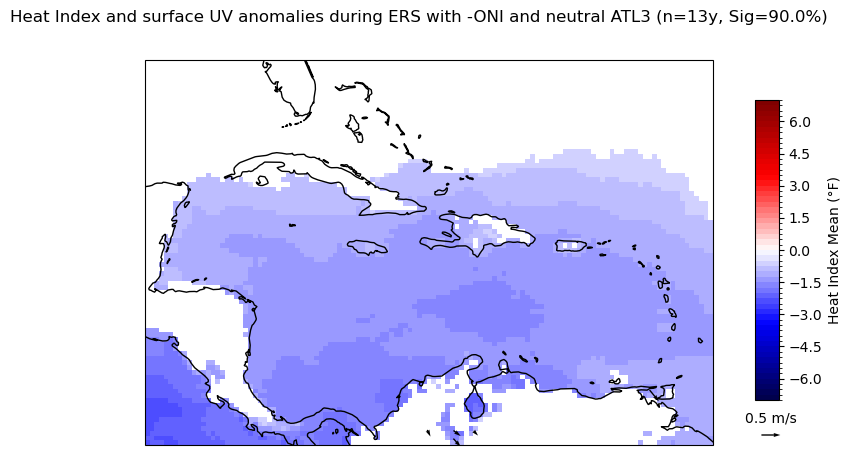

In [71]:
ERS_HI_sig_plot = ERS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = ERS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = ERS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

ERS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during ERS with -ONI and neutral ATL3 (n={ONIa_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during ERS with -ONI and neutral ATL3 (n=13y, Sig=90.0%)')

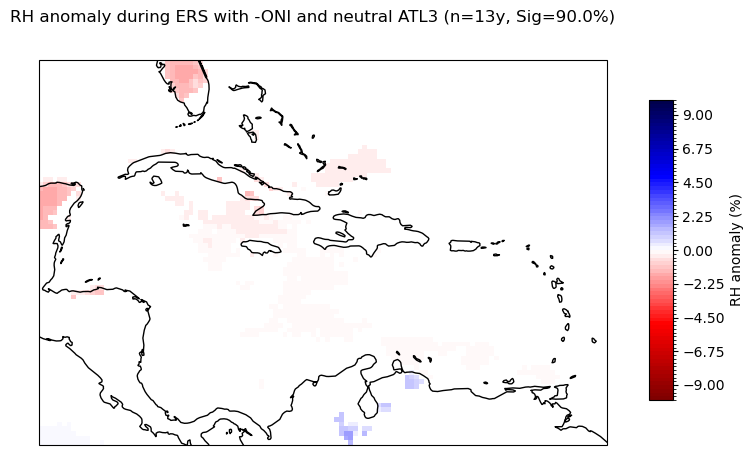

In [72]:
ERS_RH_sig_plot = ERS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

ERS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during ERS with -ONI and neutral ATL3 (n={ONIa_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during ERS with -ONI and neutral ATL3 (n=13y, Sig=90.0%)')

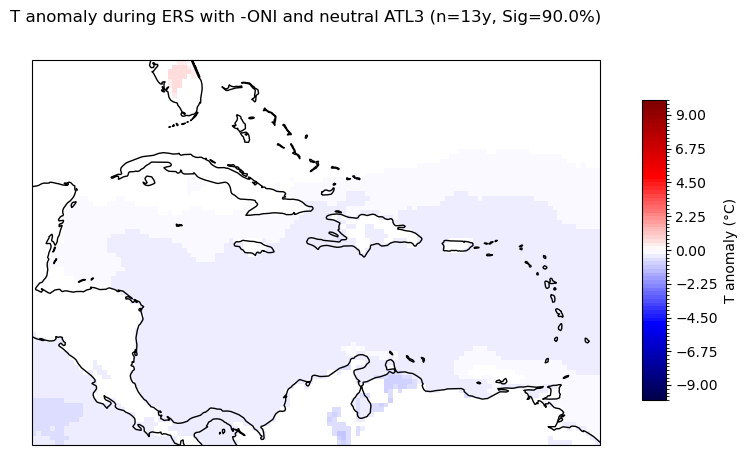

In [74]:
ERS_T_sig_plot = ERS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

ERS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during ERS with -ONI and neutral ATL3 (n={ONIa_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

### <span style="color: orange"> LRS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during LRS with -ONI and neutral ATL3 (n=12y, Sig=90.0%)')

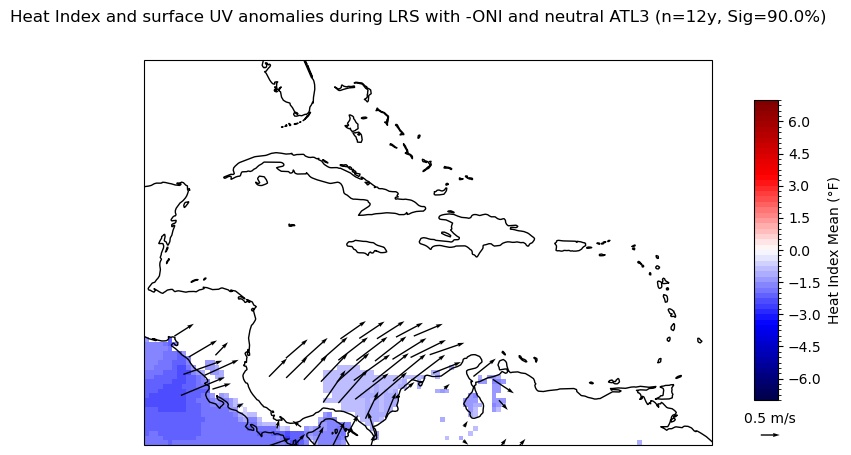

In [75]:
LRS_HI_sig_plot = LRS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = LRS_UV_sig.isel(longitude=slice(None, None, 4), latitude=slice(None, None, 4))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = LRS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

LRS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during LRS with -ONI and neutral ATL3 (n={ONIa_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during LRS with -ONI and neutral ATL3 (n=12y, Sig=90.0%)')

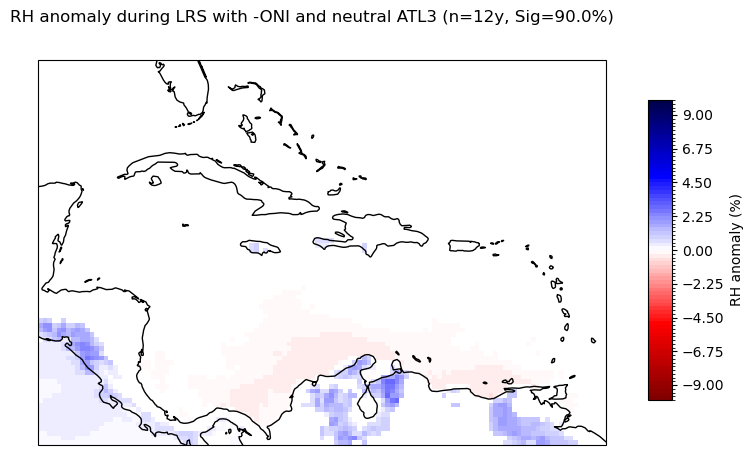

In [76]:
LRS_RH_sig_plot = LRS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

LRS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during LRS with -ONI and neutral ATL3 (n={ONIa_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during LRS with -ONI and neutral ATL3 (n=12y, Sig=90.0%)')

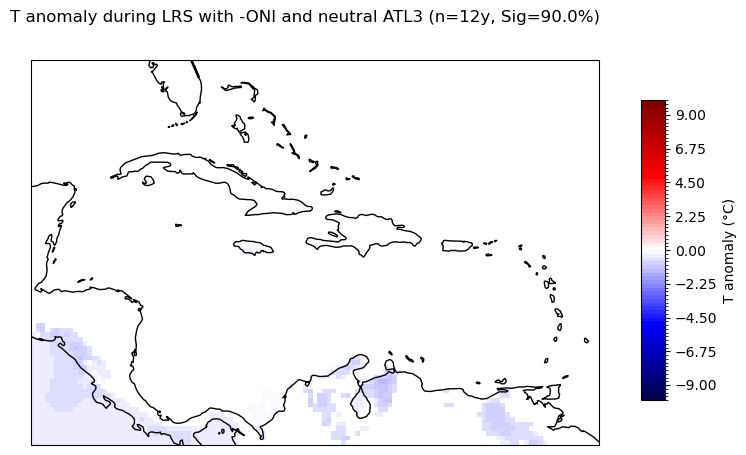

In [77]:
LRS_T_sig_plot = LRS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

LRS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during LRS with -ONI and neutral ATL3 (n={ONIa_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

# CAN and EAN?